<a href="https://colab.research.google.com/github/athfizh/PemMes26_05_Hafizh/blob/main/JS06/JS06-02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---


# **Klasifikasi 2 - Lab 2**


---

---


# **Langkah 1 - Import Library**


---

In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

---


# **Langkah 2 - Buat Kembali Fungsi Plotting**


---

In [2]:
# buat sebuah fungsi untuk menampilkan fitting data
def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none', edgecolors='k');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

---


# **Langkah 3 - Buat Data Dummy Non-Linier**


---

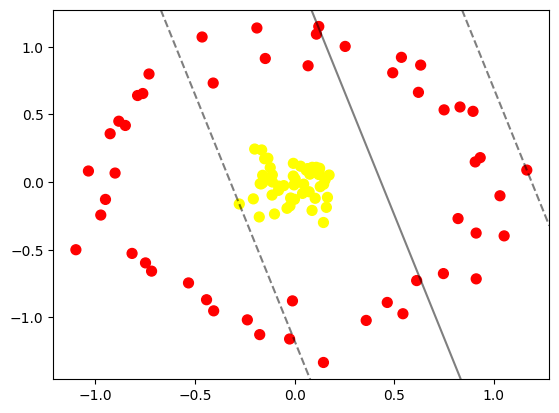

In [3]:
# contoh data tidak terpisah secara linier
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1, random_state=0)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);
plt.show()

In [4]:
print(f'Akurasi SVM kernel linier: {clf.score(X, y):.2f}')

Akurasi SVM kernel linier: 0.68


> Akurasi SVM kernel linier hanya 0,68 pada data lingkaran ini, dan garis yang terbentuk memang tidak bisa memisahkan kelas di tengah dari kelas yang mengelilinginya. Data seperti ini mustahil dipisahkan oleh satu garis lurus di ruang 2 dimensi.

---


# **Langkah 4 - Proyeksi Radial**


---

In [5]:
r = np.exp(-(X ** 2).sum(1))

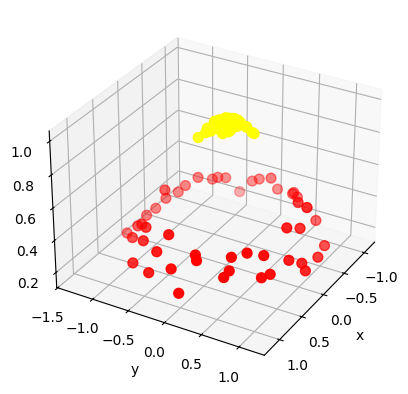

In [6]:
from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

plot_3D(elev=30, azim=30)
plt.show()

In [7]:
# versi interaktif, sudut pandang bisa diubah-ubah
interact(plot_3D, elev=[-90, 45, 30, 20, 10], azim=(-180, 180),
         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[-9.49575361e-01, -1.28130352e-01],
       [ 1.28860852e-01, -3.35507154e-02],
       [ 9.32149730e-01,  1.80812148e-01],
       [ 4.55389138e-02, -1.52962218e-02],
       [-1.67502183e-01, -1.32784256e-02],
       [ 1.25722505e-01,  1.02065522e-01],
       [-4.08679248e-01,  7.32259917e-01],
       [-8.07924621e-02, -6.10295433e-02],
       [ 6.69885738e-02,  9.70180142e-02],
       [-2.93139712e-03, -2.06621508e-02],
       [-6.11267963e-03,  1.38600460e-01],
       [ 8.77414191e-02, -2.09521414e-01],
       [-4.52573414e-04, -1.27291071e-01],
       [ 1.21578633e-01,  1.15057745e+00],
       [ 4.92870432e-01,  8.08229304e-01],
       [-8.16072717e-01, -5.27369282e-01],
       [-8.82561586e-01,  4.50116282e-01],
       [-9.01362740e-01,  6.67509461e-02],
       [-4.42070911e-01, -8.69788735e-01],
       [ 6.33186666e-01,  8.65056203e-01],
       [ 7.47388187e-01, -6.76523545e-01],
       [ 6.69179520e-02,  9.99787569e-02],
       [ 8.30760472e-01,  5.55363961e-01],
       [-1.11738027e-01,  5.35098581e-02],
       [ 9.12098589e-01, -7.15484151e-01],
       [ 1.05235514e+00, -3.97701028e-01],
       [ 6.21947127e-01,  6.63634244e-01],
       [ 1.59668698e-01, -1.86839146e-01],
       [ 8.86802823e-02,  1.09306208e-01],
       [ 2.99263219e-02,  1.17536304e-01],
       [ 1.22721982e-01,  7.92256045e-02],
       [-1.77308035e-01, -2.57856407e-01],
       [ 3.98747721e-02, -8.36202637e-02],
       [-1.22323917e-01,  1.06928528e-01],
       [ 1.21437460e-01,  5.60516201e-02],
       [-9.73157971e-01, -2.43700046e-01],
       [-7.30977035e-01,  7.99252008e-01],
       [ 1.08939589e-01,  1.09269523e-01],
       [-2.00350620e-01,  2.44286244e-01],
       [-7.99253838e-02, -2.95531587e-02],
       [ 1.16614005e+00,  8.89245560e-02],
       [ 1.53133573e-01,  1.64066289e-02],
       [ 5.44097789e-01, -9.73433771e-01],
       [ 3.59668868e-01, -1.02284615e+00],
       [ 8.96070944e-01,  5.23143672e-01],
       [-1.89284796e-01,  1.13939190e+00],
       [-4.64404413e-01,  1.07276126e+00],
       [ 4.65427252e-01, -8.89946145e-01],
       [-2.49458126e-02, -1.16013548e+00],
       [ 7.50849695e-01,  5.34001857e-01],
       [-1.13024439e-01, -9.59291896e-02],
       [-1.38549950e-01,  2.73651835e-02],
       [ 9.07184082e-01,  1.49072192e-01],
       [-4.06229358e-01, -9.51987486e-01],
       [-7.48541021e-01, -5.97538301e-01],
       [ 1.65120935e-01, -1.13049645e-01],
       [ 1.09646649e-01,  1.09388110e+00],
       [-1.75071693e-01, -1.12779988e+00],
       [-9.26141915e-01,  3.57620792e-01],
       [ 5.84397480e-02,  8.80891301e-02],
       [ 2.54051404e-01,  1.00316909e+00],
       [-7.18133673e-01, -6.58380258e-01],
       [-1.34053462e-01,  1.76306484e-01],
       [ 7.31758280e-02, -7.15390616e-02],
       [-2.77689094e-01, -1.61933287e-01],
       [-2.07105588e-01, -1.23967974e-01],
       [-5.32625767e-01, -7.45517489e-01],
       [-3.78874830e-02, -1.93707009e-01],
       [-1.47062746e-01,  9.13881326e-01],
       [ 1.44970350e-01, -2.98784384e-01],
       [-7.62171667e-01,  6.54937066e-01],
       [-1.09814276e+00, -5.00103962e-01],
       [ 1.03134551e+00, -1.01169753e-01],
       [ 1.03371240e-01, -1.19769574e-01],
       [ 1.46134255e-01, -1.58577096e-02],
       [-1.72653617e-01, -1.15491108e-02],
       [-7.88309437e-01,  6.40131555e-01],
       [ 2.95738061e-03,  2.29158701e-02],
       [-1.60256127e-01,  5.01449050e-02],
       [-5.41687141e-02, -2.61539279e-02],
       [-1.03522483e+00,  8.19466608e-02],
       [-1.05917466e-02, -8.78300742e-01],
       [-1.11145484e-01,  7.11481244e-04],
       [ 9.11695181e-01, -3.76995140e-01],
       [ 1.44991691e-01, -1.33376406e+00],
       [-1.65217372e-01,  2.37656264e-01],
       [ 7.64408806e-02,  5.86664166e-02],
       [ 6.78275911e-02,  8.60005641e-01],
       [-1.98881547e-02, -1.17740642e-01],
       [-1.50178757e-01,  1.72561212e-01],
       [-2.31947771e-02, -1.76194040e-01],
       [-2.37188625e-01, -1.01857636e+00

> Setelah ditambahkan dimensi baru berupa fungsi radial `r = exp(-(x² + y²))`, data pada plot 3D bisa dipisahkan oleh sebuah bidang datar. Titik kuning di tengah memiliki nilai r tinggi (mendekati 1) karena dekat dengan pusat, sedangkan titik merah di tepi memiliki nilai r lebih rendah. Dengan kata lain, data yang tidak terpisah secara linier di 2D menjadi terpisah secara linier di 3D. Hanya saja, menghitung proyeksi ini secara eksplisit untuk semua titik cukup memberatkan komputasi, sehingga SVM memakai kernel trick yang menghitung hasil kali dalam di ruang baru tanpa benar-benar memetakan datanya.

---


# **Langkah 5 - Fitting Model dengan Kernel RBF**


---

In [8]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

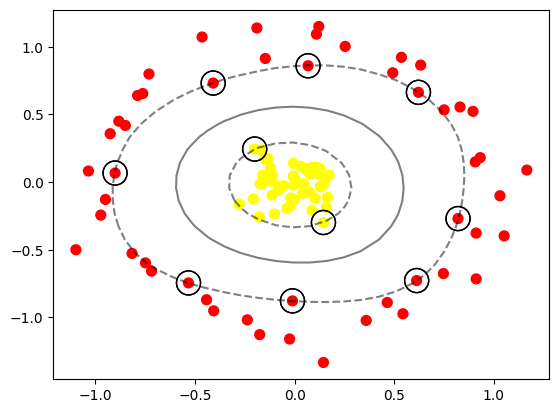

In [9]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none', edgecolors='k')
plt.show()

In [10]:
print(f'Akurasi SVM kernel RBF: {clf.score(X, y):.2f}')
print(f'Jumlah support vector: {len(clf.support_vectors_)}')

Akurasi SVM kernel RBF: 1.00
Jumlah support vector: 10


> Dengan kernel RBF (`C=1E6`), decision boundary berbentuk lingkaran yang melingkupi kelas di tengah, dan akurasinya naik menjadi 1,00 dengan 10 support vector. Bandingkan dengan kernel linier sebelumnya yang hanya mencapai 0,68. Jadi, kernel RBF mampu membuat batas yang melengkung tanpa kita harus mendefinisikan fungsi proyeksi sendiri.